In [244]:
# !pip install xlrd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression,ElasticNet
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler


# Load and clean the data
# file_path = 'Datasets/housedata.xlsx'
file_path = 'Datasets/housedata.xls'  # Adjust the path as needed

# data = pd.read_excel(file_path)
data = pd.read_excel(file_path, sheet_name='Sheet1')
data.info()
print(data.describe())
data.head()
#rename columns for better control
data.columns = ['zip', 'bedrooms', 'bathrooms', 'area', 'is_condo', 'price']
# convert from string too number and clean of ";" 
data['price'] = data['price'].astype(str).str.replace(';', '').astype(float)
duplicates = data[data.duplicated(keep=False)]
print(duplicates)

data_clean = data.drop_duplicates()
print(data_clean.shape)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 774 entries, 0 to 773
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   location                        774 non-null    int64 
 1   #bedrooms                       774 non-null    int64 
 2   #bathrooms                      774 non-null    int64 
 3   house area in 1000 square feet  774 non-null    int64 
 4   1 if condo, 0 otherwise         774 non-null    int64 
 5   selling price in 1000 dollars   774 non-null    object
dtypes: int64(5), object(1)
memory usage: 36.4+ KB
        location    #bedrooms  #bathrooms  house area in 1000 square feet  \
count  774.000000  774.000000  774.000000                      774.000000   
mean     2.583979    3.240310    1.947028                     1583.179587   
std      0.701174    0.819635    0.634119                      636.594058   
min      1.000000    1.000000    1.000000                

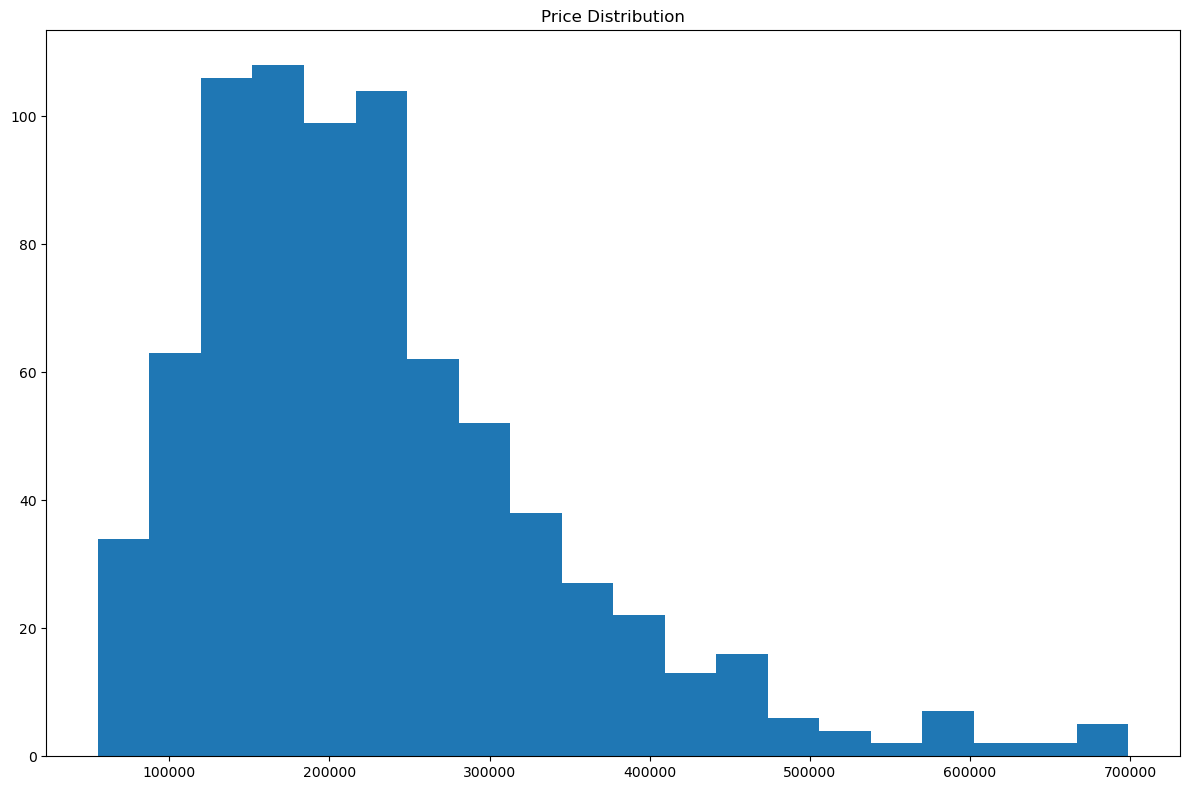

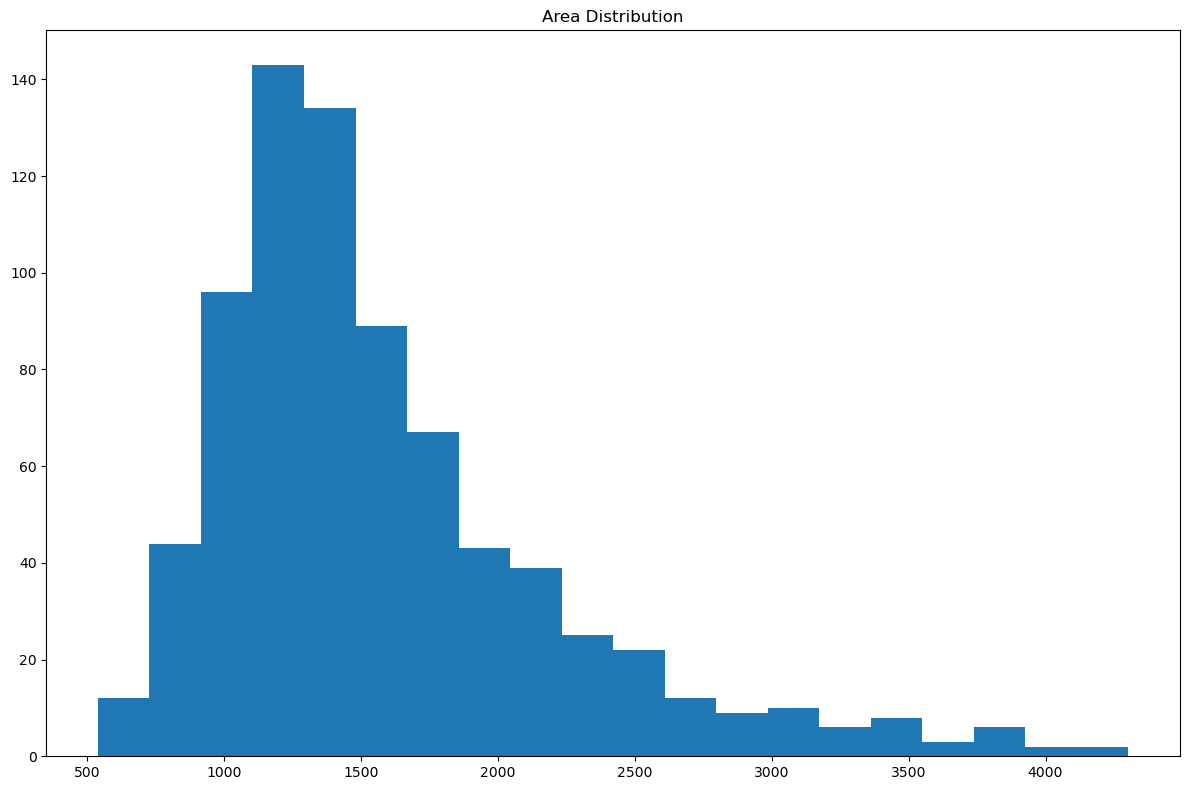

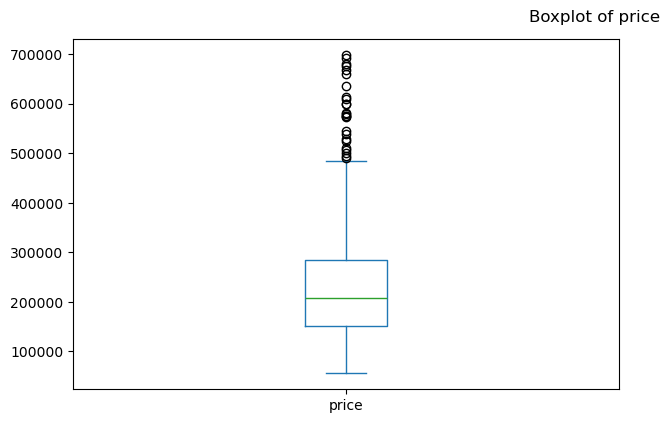

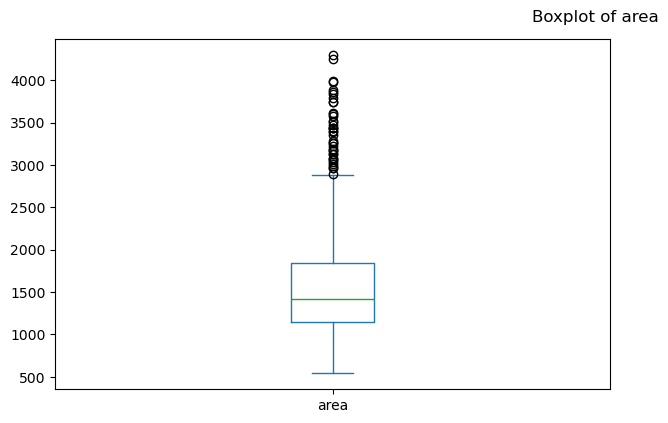

In [245]:
# Distributions

# price distribution
data_clean['price'].hist(figsize=(12, 8), bins=20, grid=False)
plt.title('Price Distribution')
plt.tight_layout()
plt.show()

# area distribution
data_clean['area'].hist(figsize=(12, 8), bins=20, grid=False)
plt.title('Area Distribution')
plt.tight_layout()
plt.show()

data_clean['price'].plot(kind='box', subplots=True, layout=(2, 2), figsize=(12, 8), title='Boxplot of price')
plt.tight_layout()
plt.show()

data_clean['area'].plot(kind='box', subplots=True, layout=(2, 2), figsize=(12, 8), title='Boxplot of area')
plt.tight_layout()
plt.show()

In [246]:
# Eκπέδευση του μοντέλου

# data_clean = data_clean[data_clean['price'] <= 500000]
# data_clean = data_clean[data_clean['area'] < 4000]

X = data_clean[['area', 'bedrooms']]
y = data_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
y_pred_entire_dataset = np.concatenate((y_train_pred, y_test_pred))

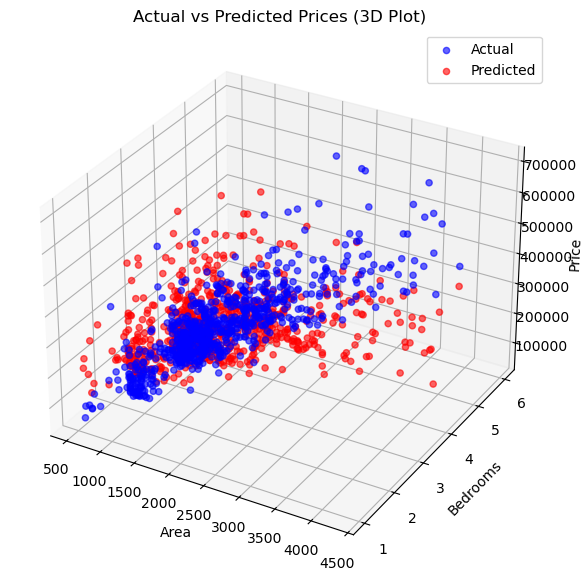

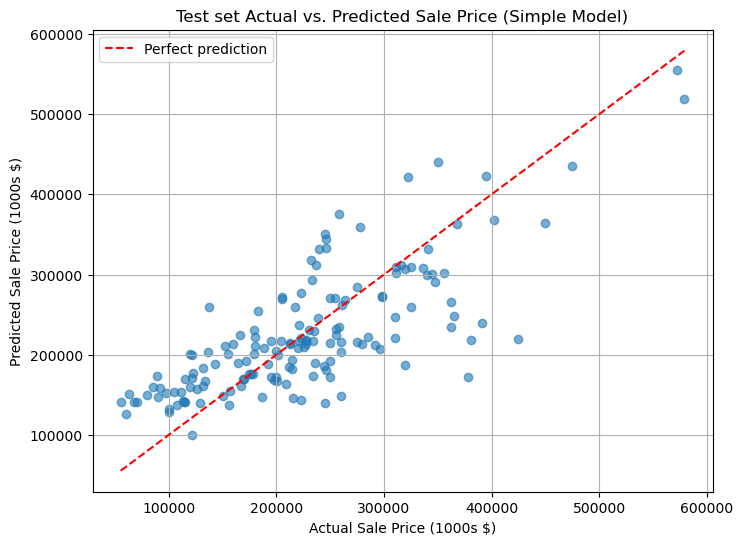

In [247]:
# Visual plots for the model performance

# Create 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
# Actual points (x1, x2, y_actual)
ax.scatter(X['area'], X['bedrooms'], y, color='blue', label='Actual', alpha=0.6)
# Predicted points (x1, x2, y_predicted)
ax.scatter(X['area'], X['bedrooms'], y_pred_entire_dataset, color='red', label='Predicted', alpha=0.6)
ax.set_xlabel('Area')
ax.set_ylabel('Bedrooms')
ax.set_zlabel('Price')
ax.set_title('Actual vs Predicted Prices (3D Plot)')
ax.legend()
plt.show()



# test set performance
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect prediction")
# the points that closest to line y=x has the lower error. So Points that fall near the line y=x indicate that the predicted values are close to the actual values,reflecting model performance
plt.xlabel("Actual Sale Price (1000s $)")
plt.ylabel("Predicted Sale Price (1000s $)")
plt.title("Test set Actual vs. Predicted Sale Price (Simple Model)")
plt.legend()
plt.grid(True)
plt.show()


In [248]:
#Evaluation model

#  Αξιολόγηση του μοντέλου (MSE, MAE, R^2) για το test set
mse_test = mean_squared_error(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_train = mean_squared_error(y_train,y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
r2_train = r2_score(y_train,y_train_pred)
evaluation = pd.DataFrame({

    'Metric': ['MSE (Test)', 'MAE (Test)', 'R^2 (Test)',"RMSE (Test)"],

    'Value': [mse_test, mae_test, r2_test,np.sqrt(mse_test)]

})
print("Evaluation test set: \n",evaluation)

rmse_train = mean_squared_error(y_train, y_train_pred, squared=False)
rmse_test = mean_squared_error(y_test, y_test_pred, squared=False)
rmse_entire = mean_squared_error(y, y_pred_entire_dataset, squared=False)

print("\nTrain RMSE:", rmse_train)
print("Test RMSE:", rmse_test)
print("Test RMSE:", rmse_entire)

Evaluation test set: 
         Metric         Value
0   MSE (Test)  3.772617e+09
1   MAE (Test)  4.764756e+04
2   R^2 (Test)  5.887396e-01
3  RMSE (Test)  6.142164e+04

Train RMSE: 77920.91404826677
Test RMSE: 61421.635902031696
Test RMSE: 140867.43744853322


C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(



Test Houses Evaluation:
    area  bedrooms  actual_price  predicted_price         error
0   846         1        115000    162054.506682 -47054.506682
1  1324         2        234500    214242.669925  20257.330075
2  1150         3        198000    168434.959117  29565.040883
3  3037         4        528000    432396.414598  95603.585402
4  3984         5        572500    555075.474973  17424.525027
Test houses MSE:  2588447455.498011
Test houses MAE:  41980.99761388125


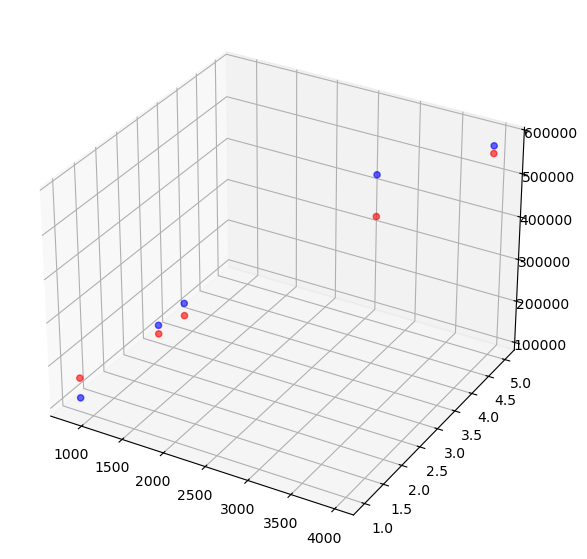

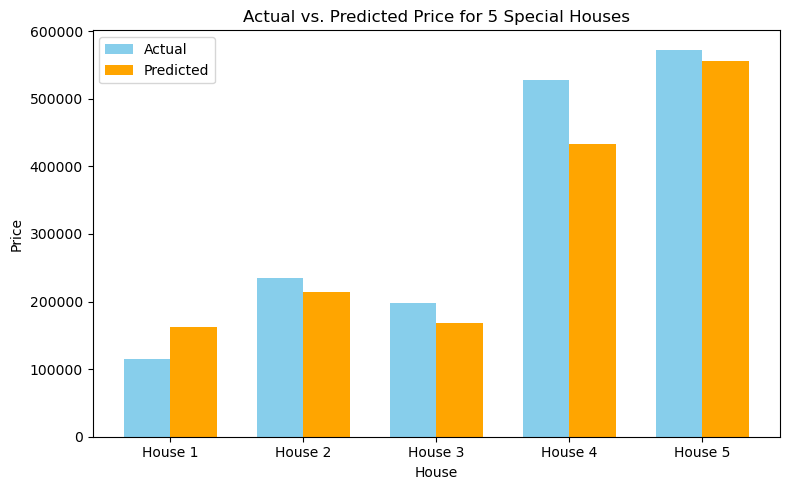

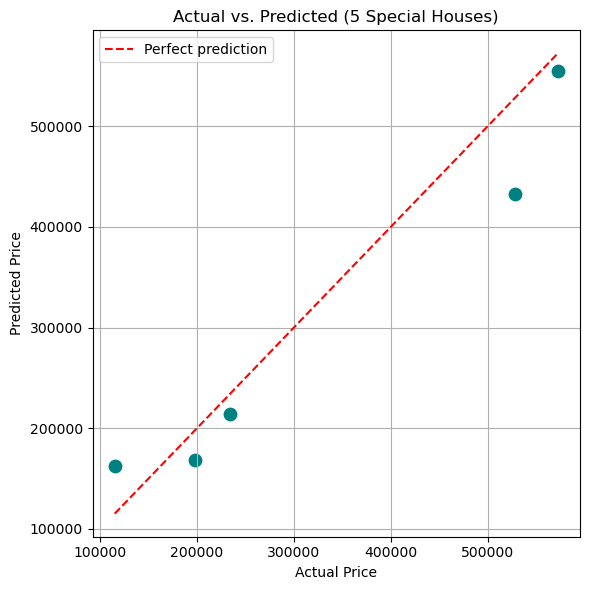

In [249]:
# Test 5 input examples

test_houses = pd.DataFrame({
    'area': [846, 1324, 1150, 3037, 3984],
    'bedrooms': [1, 2, 3, 4, 5],
    'actual_price': [115000, 234500, 198000, 528000, 572500]
})
test_houses['predicted_price'] = model.predict(test_houses[['area', 'bedrooms']])
actual_prices = test_houses['actual_price']
# Create 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(test_houses['area'], test_houses['bedrooms'], test_houses['actual_price'], color='blue', label='Actual', alpha=0.6)
ax.scatter(test_houses['area'], test_houses['bedrooms'], test_houses['predicted_price'], color='red', label='Predicted', alpha=0.6)
test_houses['error'] = test_houses['actual_price'] - test_houses['predicted_price']
print("\nTest Houses Evaluation:\n", test_houses)
# print("Test houses MAE: ",test_houses['error'].abs().mean())
# print("Test houses MSE: ",test_houses['error'].pow(2).mean())
mse_test_houses = mean_squared_error(test_houses['actual_price'], test_houses['predicted_price'])
mae_test_hoouses = mean_absolute_error(test_houses['actual_price'], test_houses['predicted_price'])
print("Test houses MSE: ",mse_test_houses)
print("Test houses MAE: ",mae_test_hoouses)

plt.figure(figsize=(8,5))
index = np.arange(len(test_houses))
bar_width = 0.35
plt.bar(index, test_houses['actual_price'], bar_width, label='Actual', color='skyblue')
plt.bar(index + bar_width, test_houses['predicted_price'], bar_width, label='Predicted', color='orange')
plt.xlabel('House')
plt.ylabel('Price')
plt.title('Actual vs. Predicted Price for 5 Special Houses')
plt.xticks(index + bar_width/2, [f'House {i+1}' for i in range(5)])
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(test_houses['actual_price'], test_houses['predicted_price'], color='teal', s=80)
plt.plot([test_houses['actual_price'].min(), test_houses['actual_price'].max()],
         [test_houses['actual_price'].min(), test_houses['actual_price'].max()],
         'r--', label="Perfect prediction")
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted (5 Special Houses)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [250]:
# cross validation simple model

# cross-validation score
scores_simple = cross_val_score(model, X, y,scoring="neg_mean_squared_error", cv=10)
cv_mse = -scores_simple
rmse_scores = np.sqrt(cv_mse)

print("\n=== Cross-Validation (5-Fold) ===")
print(f"CV MSEs: {cv_mse}")
print(f"CV MSE Μέσος όρος: {np.mean(cv_mse):.2f}, std: {np.std(cv_mse):.2f}")
print()
# 7. Έλεγχος Overfitting/Underfitting
print("\n=== Εκτίμηση Overfitting ===")
if mse_train < mse_test and abs(r2_train - r2_test) > 0.1:
    print(" Πιθανό overfitting: πολύ καλύτερη επίδοση στο train set.")
elif mse_train > mse_test:
    print(" Πιθανό underfitting: το μοντέλο δεν μαθαίνει καλά ούτε το train set.")
else:
    print(" Το μοντέλο έχει παρόμοια συμπεριφορά σε train και test.")



=== Cross-Validation (5-Fold) ===
CV MSEs: [2.42863850e+09 6.92845349e+09 1.98397096e+09 1.09619532e+10
 3.00112483e+09 1.36603292e+10 2.72520681e+09 3.43189969e+09
 1.14252292e+10 1.64072275e+09]
CV MSE Μέσος όρος: 5818752858.30, std: 4329749726.56


=== Εκτίμηση Overfitting ===
 Πιθανό underfitting: το μοντέλο δεν μαθαίνει καλά ούτε το train set.


In [ ]:
# Make features, basis and appropriate dataset to generate a more complicated model

df_comp= data_clean.copy()
df_comp['f1'] = 1
# f2(x):normalize area/1000 
df_comp['f2_area'] = df_comp['area']/1000
# f3(x): max(area - 1500, 0)
# df_comp['f3_area_over_1500'] = np.maximum(df_comp['area'] - 1500, 0)
df_comp['f3_area_over_1500'] = np.maximum(df_comp['f2_area']- 1.5, 0)

# f4(x): bedrooms
df_comp['f4_bedrooms'] = df_comp['bedrooms']
# f5(x): condo
df_comp['f5_condo'] = df_comp['is_condo']
# convert location to one hot encoding as zip-code
zip_encoded = pd.DataFrame()
zip_encoded['zip'] = data_clean['zip'].astype(int)
# make the one hot encoding columns for location as 'zip'
zip_encoded = pd.get_dummies(zip_encoded, columns=['zip'],  drop_first=True).astype(int)
print(zip_encoded)
# rename label basis index to convert the zip_2,zip_3,zip_4 to f_5,f_6,f_7,f_8, droped first zip_1
zip_encoded.rename(columns={'zip_2': 'f_6', 'zip_3': 'f_7','zip_4': 'f_8'}, inplace=True)
#concat the location one hot encoding columns to my dataframe
df_comp = pd.concat([df_comp,zip_encoded], axis=1)
# Show columns for reference
print(df_comp.columns)
print(df_comp)
df_comp.head(20)

#piecewise features

# keep only specific features + location dummies f_6,f_7,f_8
feature_cols = ['f1','f2_area', 'f3_area_over_1500', 'f4_bedrooms', 'f5_condo',] + [col for col in df_comp.columns if col.startswith('f_')]


     zip_2  zip_3  zip_4
0        1      0      0
1        1      0      0
2        1      0      0
3        0      1      0
4        0      1      0
..     ...    ...    ...
769      0      1      0
770      0      1      0
771      1      0      0
772      0      1      0
773      0      0      1

[772 rows x 3 columns]
Index(['zip', 'bedrooms', 'bathrooms', 'area', 'is_condo', 'price', 'f1',
       'f2_area', 'f3_area_over_1500', 'f4_bedrooms', 'f5_condo', 'f_6', 'f_7',
       'f_8'],
      dtype='object')
     zip  bedrooms  bathrooms  area  is_condo     price  f1  f2_area  \
0      2         2          2   941         1   94905.0   1    0.941   
1      2         3          2  1146         0   98937.0   1    1.146   
2      2         3          2   909         0  100309.0   1    0.909   
3      3         3          2  1289         0  106250.0   1    1.289   
4      3         3          1  1020         0  107502.0   1    1.020   
..   ...       ...        ...   ...       ...       .

In [252]:
# Generate linear model on selected piecewise  features: 
#'f1','f2_area', 'f3_area_over_1500', 'f4_bedrooms', 'f5_condo','f_6', 'f_7','f_8'
       
X_train_comp, X_test_comp, y_train_comp, y_test_comp = train_test_split(df_comp[feature_cols], y, test_size=0.2, random_state=42)
model_comp = LinearRegression()
model_comp.fit(X_train_comp, y_train_comp)

y_train_pred_comp = model_comp.predict(X_train_comp)
y_test_pred_comp = model_comp.predict(X_test_comp)
y_all_pred_comp = model_comp.predict(df_comp[feature_cols])

#  Αξιολόγηση του μοντέλου (MSE, MAE, R^2) για το test set
mse_test_comp = mean_squared_error(y_test, y_test_pred)
mae_test_comp = mean_absolute_error(y_test, y_test_pred)
mse_train_comp = mean_squared_error(y_train,y_train_pred)
rmse_train_comp = mean_squared_error(y_train_comp, y_train_pred_comp, squared=False)
rmse_test_comp = mean_squared_error(y_test_comp, y_test_pred_comp, squared=False)
rmse_entire_comp = mean_squared_error(y, y_all_pred_comp, squared=False)
r2_test_comp = r2_score(y_test_comp,y_test_pred_comp)
r2_train_comp = r2_score(y_train_comp,y_train_pred_comp)
r2_all_comp = r2_score(y,y_all_pred_comp)


print(f"Complicated Model - Training MSE: {mse_train_comp:,.2f}")
print(f"Complicated Model - Test MSE:     {mse_test_comp:,.2f}")
print(f"Complicated Model - Test MAE:     {mae_test_comp:,.2f}")
print(f"Complicated Model - Training RMSE: {rmse_train_comp:,.2f}")
print(f"Complicated Model - Test RMSE:     {rmse_test_comp:,.2f}")
print(f"Complicated Model - Test R2:     {r2_test_comp:,.2f}")
print(f"Complicated Model - Train R2:     {r2_train_comp:,.2f}")
print(f"Complicated Model - Entire R2:     {r2_all_comp:,.2f}")
print(f"Complicated Model - Entire RMSE: {rmse_entire_comp:,.2f}")




print("Intercept:", model_comp.intercept_)
print("Coefficients:", model_comp.coef_)


Complicated Model - Training MSE: 6,071,668,846.12
Complicated Model - Test MSE:     3,772,617,356.88
Complicated Model - Test MAE:     47,647.56
Complicated Model - Training RMSE: 71,283.30
Complicated Model - Test RMSE:     55,954.12
Complicated Model - Test R2:     0.66
Complicated Model - Train R2:     0.63
Complicated Model - Entire R2:     0.63
Complicated Model - Entire RMSE: 68,481.41
Intercept: 108552.70834404617
Coefficients: [      0.          172795.08267184  -37661.45735742  -17403.89629304
  -19229.94498208  -91953.97149421 -102737.46127535  -10963.65558628]


C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


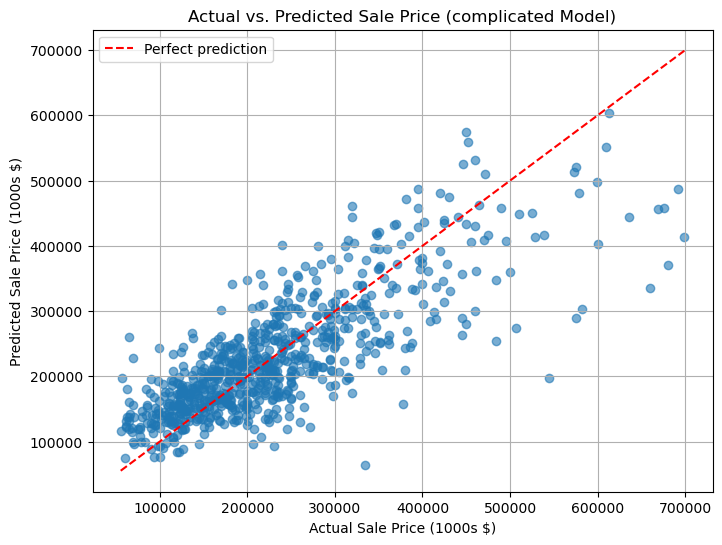

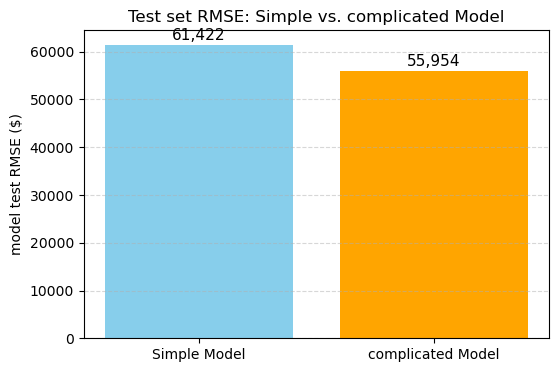

In [253]:
# visualize performance of complicate model

plt.figure(figsize=(8,6))
plt.scatter(df_comp['price'], y_all_pred_comp, alpha=0.6)
plt.plot([df_comp['price'].min(), df_comp['price'].max()],
         [df_comp['price'].min(), df_comp['price'].max()],
         'r--', label="Perfect prediction")
plt.xlabel("Actual Sale Price (1000s $)")
plt.ylabel("Predicted Sale Price (1000s $)")
plt.title("Actual vs. Predicted Sale Price (complicated Model)")
plt.legend()
plt.grid(True)
plt.show()

RMSEs = [rmse_test, rmse_test_comp]
labels = ['Simple Model', 'complicated Model']
plt.figure(figsize=(6,4))
bars = plt.bar(labels, RMSEs, color=['skyblue', 'orange'])
plt.ylabel("model test RMSE ($)")
plt.title("Test set RMSE: Simple vs. complicated Model")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Annotate values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 500, f'{height:,.0f}',
             ha='center', va='bottom', fontsize=11)

plt.show()

In [254]:
# Cross validation complicate model

# cross-validation companced model
scores_comp = cross_val_score(model, df_comp[feature_cols], y,scoring="neg_mean_squared_error", cv=10)
cv_mse_comp = -scores_comp
rmse_scores_comp = np.sqrt(-scores_comp)

# print("Simple Model CV RMSE (per fold):", np.round(rmse_scores_simple, 2))
# print("Simple Model CV RMSE (mean):", np.round(rmse_scores_simple.mean(), 2))

print("\n=== Cross-Validation (5-Fold) companced model===")
print(f"CV MSEs: {cv_mse_comp}")
print(f"CV MSE Μέσος όρος: {np.mean(cv_mse_comp):.2f}, std: {np.std(cv_mse_comp):.2f}")
print()
# 7. Έλεγχος Overfitting/Underfitting
print("\n=== Εκτίμηση Over/under-fitting ===")
if rmse_train_comp < rmse_test_comp and abs(r2_train_comp - r2_test_comp) > 0.1:
    print(" Πιθανό overfitting: πολύ καλύτερη επίδοση στο train set.")
elif rmse_train_comp > rmse_test_comp:
    print(" Πιθανό underfitting: το μοντέλο δεν μαθαίνει καλά ούτε το train set.")
else:
    print(" Το μοντέλο έχει παρόμοια συμπεριφορά σε train και test.")


print("\n=== Cross-Validation (5-Fold) COmplicated model===")
print(f"CV MSEs: {cv_mse_comp}")
print(f"CV MSE Μέσος όρος: {np.mean(cv_mse_comp):.2f}, std: {np.std(cv_mse_comp):.2f}")


=== Cross-Validation (5-Fold) companced model===
CV MSEs: [2.35717663e+09 6.32440135e+09 1.84914306e+09 8.59288761e+09
 3.70650451e+09 1.11507604e+10 2.59392293e+09 2.68052376e+09
 8.72016038e+09 2.26195811e+09]
CV MSE Μέσος όρος: 5023743878.21, std: 3218389125.12


=== Εκτίμηση Over/under-fitting ===
 Πιθανό underfitting: το μοντέλο δεν μαθαίνει καλά ούτε το train set.

=== Cross-Validation (5-Fold) COmplicated model===
CV MSEs: [2.35717663e+09 6.32440135e+09 1.84914306e+09 8.59288761e+09
 3.70650451e+09 1.11507604e+10 2.59392293e+09 2.68052376e+09
 8.72016038e+09 2.26195811e+09]
CV MSE Μέσος όρος: 5023743878.21, std: 3218389125.12


C:\Users\User\AppData\Local\Temp\ipykernel_3268\922945729.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([rmse_scores, rmse_scores_comp], labels=['Simple Model', 'complicated Model'])


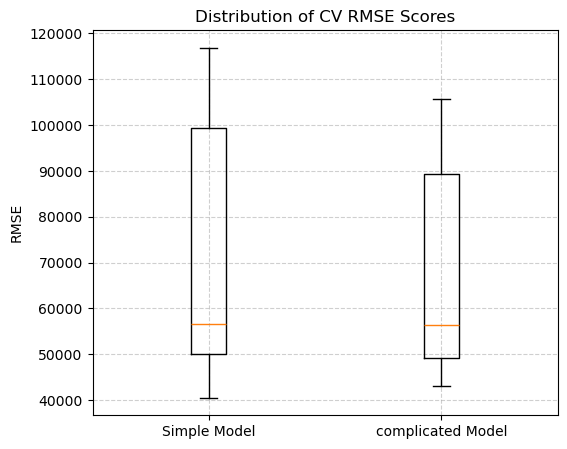

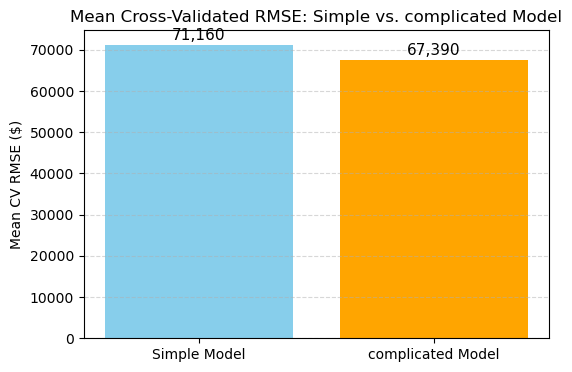

In [255]:
# Visualize comparing both each other performance
plt.figure(figsize=(6,5))
plt.boxplot([rmse_scores, rmse_scores_comp], labels=['Simple Model', 'complicated Model'])
plt.ylabel('RMSE')
plt.title('Distribution of CV RMSE Scores')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

means = [rmse_scores.mean(), rmse_scores_comp.mean()]
labels = ['Simple Model', 'complicated Model']

plt.figure(figsize=(6,4))
bars = plt.bar(labels, means, color=['skyblue', 'orange'])
plt.ylabel("Mean CV RMSE ($)")
plt.title("Mean Cross-Validated RMSE: Simple vs. complicated Model")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Annotate values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 500, f'{height:,.0f}',
             ha='center', va='bottom', fontsize=11)

plt.show()